# 🔫 1D CNN Gunshot Detector — Raw Waveform Classification

A **complete pipeline** that classifies 250ms audio clips as **gunshot** or **non-gunshot** using a 1D Convolutional Neural Network operating directly on raw audio waveforms.

## Why 1D CNN First?
- **Zero feature engineering** — the model learns directly from the raw waveform
- **Sanity check** — if this can't separate gunshots from noise, the DATA has a problem
- **Baseline** — compare against the 2D CNN (Mel Spectrogram) to measure the value of feature extraction
- **Lightweight** — fewer parameters, faster training, easier to debug

## How To Use
1. Set `DATA_DIR` in Cell 3 to your trimmed data folder (containing `class_0_nongunshot/` and `class_1_gunshot/`)
2. Run all cells in order
3. Check results in Cell 9-10

See `manual/README.md` for complete theory and documentation.

In [1]:
# ============================================================
# CELL 1: Install Dependencies
# ============================================================
%pip install -q tensorflow librosa soundfile scikit-learn matplotlib seaborn tqdm pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================
# CELL 2: Imports
# ============================================================
import os
import re
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
import warnings
import random
import json
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score,
    fbeta_score, roc_curve
)
import IPython.display as ipd

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print(f'TensorFlow: {tf.__version__}')
print(f'GPU Available: {len(tf.config.list_physical_devices("GPU")) > 0}')
print('✅ All imports loaded.')

c:\ProgramData\anaconda3\envs\guns\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow: 2.21.0
GPU Available: False
✅ All imports loaded.


In [ ]:
# ============================================================
# CELL 3: CONFIGURATION — CHANGE YOUR PATHS AND SETTINGS HERE
# ============================================================

# ==========================================================
# DATA PATH — Point this to your trimmed data folder
# Must contain: class_0_nongunshot/ and class_1_gunshot/
# ==========================================================
DATA_DIR = Path(r'C:\order\Desktop\Gun\Shoot_Catcher\Data\READY_1D_CNN')

# ==========================================================
# SAMPLE RATE — Choose your working sample rate
# ==========================================================
SAMPLE_RATE = 22050       # Native quality (matches trimmer output)
# SAMPLE_RATE = 16000     # Uncomment for Arduino-deployment mode

# ==========================================================
# AUDIO PARAMETERS
# ==========================================================
CLIP_DURATION_MS = 750
TARGET_SAMPLES = int(SAMPLE_RATE * CLIP_DURATION_MS / 1000)

# ==========================================================
# TRAINING PARAMETERS
# ==========================================================
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 0.001
VALIDATION_SPLIT = 0.15   # 15% for validation
TEST_SPLIT = 0.15         # 15% for test (held-out entire source files)
N_FOLDS = 5               # GroupKFold folds

# ==========================================================
# AUGMENTATION — Only applied to training data
# ==========================================================
USE_AUGMENTATION = True
USE_ONLY_CLEAN = True     # True = use only '_clean' files for splitting
                          # (augmented files added to training only)

# ==========================================================
# SHUFFLER — Shuffle data before everything
# ==========================================================
SHUFFLE_DATA = True

# ==========================================================
# OUTPUT
# ==========================================================
OUTPUT_DIR = Path.cwd().resolve() / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Print config ---
print(f'\n{"=" * 60}')
print(f'1D CNN GUNSHOT DETECTOR — CONFIGURATION')
print(f'{"=" * 60}')
print(f'Data Directory   : {DATA_DIR}')
print(f'Sample Rate      : {SAMPLE_RATE:,} Hz')
print(f'Clip Duration    : {CLIP_DURATION_MS}ms ({TARGET_SAMPLES:,} samples)')
print(f'Batch Size       : {BATCH_SIZE}')
print(f'Epochs           : {EPOCHS}')
print(f'Use Clean Only   : {USE_ONLY_CLEAN}')
print(f'Augmentation     : {USE_AUGMENTATION}')
print(f'Shuffle          : {SHUFFLE_DATA}')
print(f'Output           : {OUTPUT_DIR}')
print(f'{"=" * 60}')


1D CNN GUNSHOT DETECTOR — CONFIGURATION
Data Directory   : C:\order\Desktop\Gun\Shoot_Catcher\Data\READY_1D_CNN
Sample Rate      : 22,050 Hz
Clip Duration    : 250ms (5,512 samples)
Batch Size       : 64
Epochs           : 50
Use Clean Only   : True
Augmentation     : True
Shuffle          : True
Output           : C:\order\Desktop\Gun\Shoot_Catcher\01_1D_CNN\output



📂 Loading data from: C:\order\Desktop\Gun\Shoot_Catcher\Data\READY_1D_CNN

Detected class folders:
  class_0_nongunshot → Class 0 (NON-GUNSHOT)
  class_1_gunshot → Class 1 (GUNSHOT)
🔀 Data shuffled.

DATASET SUMMARY
Total files      : 59,143
🔫 Gunshot (1)   : 4,317 (7.3%)
🎵 Non-gunshot (0): 54,826 (92.7%)
Ratio (GS:NGS)   : 1 : 12.7
Unique sources   : 59,143


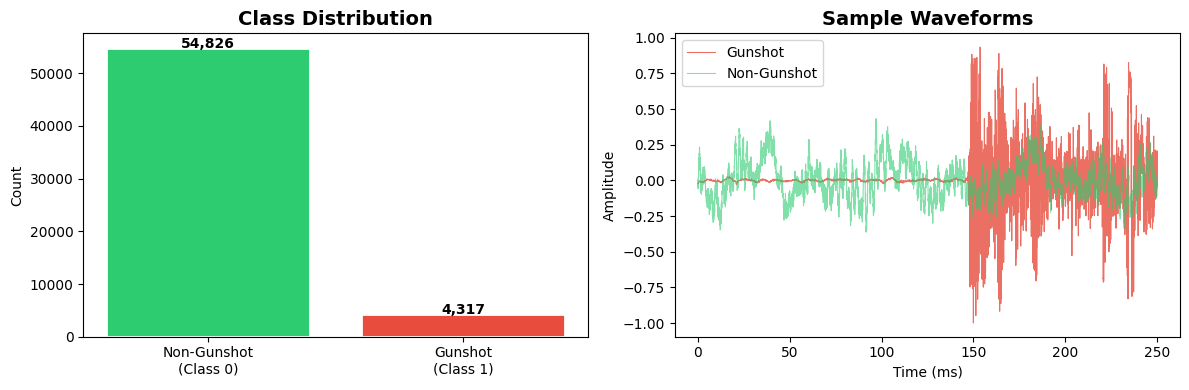


🔊 Sample gunshot:


🔊 Sample non-gunshot:


In [4]:
# ============================================================
# CELL 4: Data Loading, Exploration & Shuffling
# ============================================================

def extract_source_group(filename):
    """
    Extract the source recording identifier from a filename.
    This is used for GroupKFold to prevent data leakage.
    
    Files from the same source recording share the same group.
    e.g., 'c1_000001_SA_004A_S01_clip0_clean.wav' → 'SA_004A_S01'
          'c0_000001_Street_Sounds____60min__Sleep_Video_050_clip0.wav' → 'Street_Sounds____60min__Sleep_Video_050'
    """
    stem = Path(filename).stem
    # Remove class prefix (c0_000001_ or c1_000001_)
    no_prefix = re.sub(r'^c[01]_\d+_', '', stem)
    # Remove clip suffix (_clip0, _clip1, _aug_5dB, etc.)
    no_suffix = re.sub(r'_clip\d+.*$', '', no_prefix)
    # Remove augmentation markers
    no_aug = re.sub(r'_aug_\d+dB$', '', no_suffix)
    return no_aug if no_aug else stem


def is_clean_file(filename):
    """Check if a file is a 'clean' (non-augmented) version."""
    stem = Path(filename).stem
    return '_aug_' not in stem


def collect_audio_files(data_dir, use_only_clean=True):
    """
    Collect all audio files from the data directory.
    
    Expected structure:
        data_dir/
            class_0_nongunshot/   (or any folder with 'class_0' or 'nongunshot')
            class_1_gunshot/      (or any folder with 'class_1' or 'gunshot')
    
    Also supports flat structure with filename-based labeling.
    """
    data_dir = Path(data_dir)
    files = []
    labels = []
    groups = []
    
    # Auto-detect folder structure
    subdirs = [d for d in data_dir.iterdir() if d.is_dir()]
    
    class_map = {}
    for d in subdirs:
        name = d.name.lower()
        if 'class_0' in name or 'nongunshot' in name or 'background' in name or 'noise' in name:
            class_map[d] = 0
        elif 'class_1' in name or 'gunshot' in name or 'gun' in name:
            class_map[d] = 1
    
    if not class_map:
        raise ValueError(
            f'Could not auto-detect class folders in {data_dir}.\n'
            f'Found: {[d.name for d in subdirs]}\n'
            f'Expected folders containing: class_0/nongunshot AND class_1/gunshot'
        )
    
    print(f'Detected class folders:')
    for folder, label in class_map.items():
        label_name = 'GUNSHOT' if label == 1 else 'NON-GUNSHOT'
        print(f'  {folder.name} → Class {label} ({label_name})')
    
    # Collect files
    for folder, label in class_map.items():
        wav_files = sorted(folder.glob('*.wav'))
        
        for f in wav_files:
            # Optionally filter to clean-only
            if use_only_clean and not is_clean_file(f.name):
                continue
            
            files.append(str(f))
            labels.append(label)
            groups.append(extract_source_group(f.name))
    
    return files, labels, groups


# --- Load file list ---
print(f'\n📂 Loading data from: {DATA_DIR}\n')
all_files, all_labels, all_groups = collect_audio_files(DATA_DIR, USE_ONLY_CLEAN)

# --- Shuffle ---
if SHUFFLE_DATA:
    combined = list(zip(all_files, all_labels, all_groups))
    random.shuffle(combined)
    all_files, all_labels, all_groups = zip(*combined)
    all_files = list(all_files)
    all_labels = list(all_labels)
    all_groups = list(all_groups)
    print('🔀 Data shuffled.')

# --- Summary ---
labels_arr = np.array(all_labels)
n_gunshot = int(np.sum(labels_arr == 1))
n_nongunshot = int(np.sum(labels_arr == 0))
n_groups = len(set(all_groups))

print(f'\n{"=" * 50}')
print(f'DATASET SUMMARY')
print(f'{"=" * 50}')
print(f'Total files      : {len(all_files):,}')
print(f'🔫 Gunshot (1)   : {n_gunshot:,} ({n_gunshot/len(all_files)*100:.1f}%)')
print(f'🎵 Non-gunshot (0): {n_nongunshot:,} ({n_nongunshot/len(all_files)*100:.1f}%)')
print(f'Ratio (GS:NGS)   : 1 : {n_nongunshot/max(1,n_gunshot):.1f}')
print(f'Unique sources   : {n_groups:,}')
print(f'{"=" * 50}')

# --- Visualize distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Non-Gunshot\n(Class 0)', 'Gunshot\n(Class 1)'],
            [n_nongunshot, n_gunshot], color=colors, edgecolor='white', linewidth=2)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([n_nongunshot, n_gunshot]):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Sample waveforms
gs_file = next(f for f, l in zip(all_files, all_labels) if l == 1)
ngs_file = next(f for f, l in zip(all_files, all_labels) if l == 0)

y_gs, _ = librosa.load(gs_file, sr=SAMPLE_RATE, mono=True)
y_ngs, _ = librosa.load(ngs_file, sr=SAMPLE_RATE, mono=True)

t = np.arange(min(len(y_gs), TARGET_SAMPLES)) / SAMPLE_RATE * 1000
axes[1].plot(t, y_gs[:len(t)], alpha=0.8, label='Gunshot', color='#e74c3c', linewidth=0.8)
axes[1].plot(t, y_ngs[:len(t)], alpha=0.6, label='Non-Gunshot', color='#2ecc71', linewidth=0.8)
axes[1].set_title('Sample Waveforms', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Amplitude')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'data_distribution.png', dpi=150)
plt.show()

# Audio playback
print('\n🔊 Sample gunshot:')
display(ipd.Audio(y_gs, rate=SAMPLE_RATE))
print('🔊 Sample non-gunshot:')
display(ipd.Audio(y_ngs, rate=SAMPLE_RATE))

In [5]:
# ============================================================
# CELL 5: GroupKFold Splitting — Prevent Data Leakage
# ============================================================

def load_audio_clip(filepath, target_sr, target_samples):
    """Load and force-normalize a single audio clip."""
    try:
        y, _ = librosa.load(filepath, sr=target_sr, mono=True)
        y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)
        
        # Force exact length
        if len(y) >= target_samples:
            y = y[:target_samples]
        else:
            y = np.pad(y, (0, target_samples - len(y)), mode='constant')
        
        # Normalize to [-1, 1]
        peak = np.max(np.abs(y))
        if peak > 1e-6:
            y = y / peak
        
        return y.astype(np.float32)
    except Exception as e:
        return None


# --- Split by source groups (NOT randomly) ---
print('🔀 Splitting data using GroupKFold (by source recording)...\n')

# Get unique groups and assign to train/test
unique_groups = list(set(all_groups))
random.shuffle(unique_groups)

n_test_groups = max(1, int(len(unique_groups) * TEST_SPLIT))
test_groups = set(unique_groups[:n_test_groups])
train_val_groups = set(unique_groups[n_test_groups:])

# Split into train+val and test
train_val_files, train_val_labels, train_val_group_ids = [], [], []
test_files, test_labels = [], []

for f, l, g in zip(all_files, all_labels, all_groups):
    if g in test_groups:
        test_files.append(f)
        test_labels.append(l)
    else:
        train_val_files.append(f)
        train_val_labels.append(l)
        train_val_group_ids.append(g)

# Further split train+val into train and val (also by group)
tv_unique_groups = list(set(train_val_group_ids))
random.shuffle(tv_unique_groups)
n_val_groups = max(1, int(len(tv_unique_groups) * (VALIDATION_SPLIT / (1 - TEST_SPLIT))))
val_groups = set(tv_unique_groups[:n_val_groups])

train_files, train_labels = [], []
val_files, val_labels = [], []

for f, l, g in zip(train_val_files, train_val_labels, train_val_group_ids):
    if g in val_groups:
        val_files.append(f)
        val_labels.append(l)
    else:
        train_files.append(f)
        train_labels.append(l)

# --- If Option C: Add augmented files to training set ONLY ---
if USE_ONLY_CLEAN:
    print('📦 Option C: Adding augmented files to TRAINING set only...')
    train_groups_set = set(extract_source_group(Path(f).name) for f in train_files)
    
    # Find augmented files whose source group is in training
    for folder_path, label in [(DATA_DIR / 'class_1_gunshot', 1), (DATA_DIR / 'class_0_nongunshot', 0)]:
        if not folder_path.exists():
            # Try auto-detect
            for d in DATA_DIR.iterdir():
                if d.is_dir():
                    name = d.name.lower()
                    if label == 1 and ('class_1' in name or 'gunshot' in name):
                        folder_path = d
                    elif label == 0 and ('class_0' in name or 'nongunshot' in name):
                        folder_path = d
        
        if folder_path.exists():
            for f in folder_path.glob('*.wav'):
                if not is_clean_file(f.name):  # Only augmented files
                    group = extract_source_group(f.name)
                    if group in train_groups_set:
                        train_files.append(str(f))
                        train_labels.append(label)
    
    # Shuffle training set again
    combined = list(zip(train_files, train_labels))
    random.shuffle(combined)
    train_files, train_labels = zip(*combined)
    train_files = list(train_files)
    train_labels = list(train_labels)

# --- Print split summary ---
print(f'\n{"=" * 60}')
print(f'DATA SPLIT SUMMARY (GroupKFold — no leakage)')
print(f'{"=" * 60}')
for name, files, lbls in [('TRAIN', train_files, train_labels),
                           ('VAL', val_files, val_labels),
                           ('TEST', test_files, test_labels)]:
    arr = np.array(lbls)
    gs = int(np.sum(arr == 1))
    ngs = int(np.sum(arr == 0))
    print(f'  {name:5s}: {len(files):>6,} files | 🔫 {gs:>5,} gunshots | 🎵 {ngs:>5,} non-gunshots')
print(f'{"=" * 60}')
print(f'\n✅ Test set contains ONLY files from source recordings')
print(f'   that the model has NEVER seen during training.')

🔀 Splitting data using GroupKFold (by source recording)...

📦 Option C: Adding augmented files to TRAINING set only...

DATA SPLIT SUMMARY (GroupKFold — no leakage)
  TRAIN: 41,401 files | 🔫 2,970 gunshots | 🎵 38,431 non-gunshots
  VAL  :  8,871 files | 🔫   675 gunshots | 🎵 8,196 non-gunshots
  TEST :  8,871 files | 🔫   672 gunshots | 🎵 8,199 non-gunshots

✅ Test set contains ONLY files from source recordings
   that the model has NEVER seen during training.


In [6]:
# ============================================================
# CELL 6: Load Audio & Data Augmentation
# ============================================================

def augment_waveform(y, sr):
    """
    Apply random augmentations to a raw waveform.
    Only applied during training.
    """
    augmented = y.copy()
    
    # 1. Time shift (±10% of duration)
    if random.random() < 0.5:
        shift = int(len(augmented) * random.uniform(-0.1, 0.1))
        augmented = np.roll(augmented, shift)
    
    # 2. Add noise (SNR between 15-30 dB)
    if random.random() < 0.5:
        snr_db = random.uniform(15, 30)
        signal_power = np.mean(augmented ** 2)
        noise_power = signal_power / (10 ** (snr_db / 10))
        noise = np.random.normal(0, np.sqrt(max(noise_power, 1e-10)), len(augmented))
        augmented = augmented + noise.astype(np.float32)
    
    # 3. Gain variation (±6 dB)
    if random.random() < 0.5:
        gain_db = random.uniform(-6, 6)
        gain = 10 ** (gain_db / 20)
        augmented = augmented * gain
    
    # Re-normalize
    peak = np.max(np.abs(augmented))
    if peak > 1e-6:
        augmented = augmented / peak
    
    return augmented.astype(np.float32)


def load_dataset(file_list, label_list, sr, target_samples, augment=False):
    """
    Load all audio files into numpy arrays.
    Returns X: (N, target_samples, 1), y: (N,)
    """
    X, y = [], []
    failed = 0
    
    for filepath, label in tqdm(zip(file_list, label_list),
                                total=len(file_list),
                                desc='Loading audio'):
        clip = load_audio_clip(filepath, sr, target_samples)
        if clip is None:
            failed += 1
            continue
        
        X.append(clip)
        y.append(label)
        
        # Augment training data on-the-fly
        if augment and USE_AUGMENTATION:
            aug_clip = augment_waveform(clip, sr)
            X.append(aug_clip)
            y.append(label)
    
    if failed > 0:
        print(f'  ⚠️ {failed} files failed to load.')
    
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    
    # Reshape for Conv1D: (N, timesteps, channels)
    X = X.reshape(-1, target_samples, 1)
    
    return X, y


# --- Load all splits ---
print('\n📥 Loading TRAINING data...')
X_train, y_train = load_dataset(train_files, train_labels, SAMPLE_RATE, TARGET_SAMPLES, augment=True)

print('\n📥 Loading VALIDATION data...')
X_val, y_val = load_dataset(val_files, val_labels, SAMPLE_RATE, TARGET_SAMPLES, augment=False)

print('\n📥 Loading TEST data...')
X_test, y_test = load_dataset(test_files, test_labels, SAMPLE_RATE, TARGET_SAMPLES, augment=False)

# --- Summary ---
print(f'\n{"=" * 50}')
print(f'LOADED DATA SHAPES')
print(f'{"=" * 50}')
print(f'X_train : {X_train.shape}  |  y_train : {y_train.shape}')
print(f'X_val   : {X_val.shape}  |  y_val   : {y_val.shape}')
print(f'X_test  : {X_test.shape}  |  y_test  : {y_test.shape}')
print(f'{"=" * 50}')


📥 Loading TRAINING data...


Loading audio: 100%|██████████| 41401/41401 [03:10<00:00, 217.50it/s]



📥 Loading VALIDATION data...


Loading audio: 100%|██████████| 8871/8871 [00:04<00:00, 1796.44it/s]



📥 Loading TEST data...


Loading audio: 100%|██████████| 8871/8871 [00:04<00:00, 1832.99it/s]



LOADED DATA SHAPES
X_train : (82802, 5512, 1)  |  y_train : (82802,)
X_val   : (8871, 5512, 1)  |  y_val   : (8871,)
X_test  : (8871, 5512, 1)  |  y_test  : (8871,)


In [7]:
# ============================================================
# CELL 7: 1D CNN Architecture (Research-Backed)
# ============================================================
#
# Architecture rationale (from 2024-2025 research):
# - First Conv1D layer uses a LARGE kernel (80 samples ≈ 3.6ms at 22kHz)
#   to capture impulsive transients (the "bang" of a gunshot)
# - Subsequent layers use small kernels (3) to refine patterns
# - BatchNorm after every conv for stable training
# - GlobalAveragePooling instead of Flatten (reduces overfitting)
# - Dropout for regularization
# ============================================================

def build_1d_cnn(input_shape):
    """
    Build a multi-scale 1D CNN for raw audio classification.
    
    Architecture:
      Conv1D(32, 80, stride=4)  → Captures ~3.6ms patterns (gunshot transient)
      MaxPool(4)
      Conv1D(64, 3)             → Refines local patterns  
      MaxPool(4)
      Conv1D(128, 3)            → Higher-level features
      Conv1D(128, 3)            → Further refinement
      GlobalAvgPool             → Reduce to single vector
      Dense(64) + Dropout       → Classification head
      Dense(1, sigmoid)         → Binary output
    """
    model = models.Sequential([
        # --- Layer 1: Wide kernel to capture impulsive transients ---
        layers.Conv1D(32, kernel_size=80, strides=4, activation='relu',
                      padding='same', input_shape=input_shape,
                      name='conv1_wide'),
        layers.BatchNormalization(name='bn1'),
        layers.MaxPooling1D(pool_size=4, name='pool1'),
        
        # --- Layer 2: Narrow kernel refinement ---
        layers.Conv1D(64, kernel_size=3, activation='relu',
                      padding='same', name='conv2'),
        layers.BatchNormalization(name='bn2'),
        layers.MaxPooling1D(pool_size=4, name='pool2'),
        
        # --- Layer 3: Higher-level features ---
        layers.Conv1D(128, kernel_size=3, activation='relu',
                      padding='same', name='conv3'),
        layers.BatchNormalization(name='bn3'),
        
        # --- Layer 4: Further refinement ---
        layers.Conv1D(128, kernel_size=3, activation='relu',
                      padding='same', name='conv4'),
        layers.BatchNormalization(name='bn4'),
        
        # --- Global pooling (better than Flatten for generalization) ---
        layers.GlobalAveragePooling1D(name='gap'),
        
        # --- Classification head ---
        layers.Dense(64, activation='relu', name='dense1'),
        layers.Dropout(0.4, name='dropout'),
        layers.Dense(1, activation='sigmoid', name='output')
    ], name='1D_CNN_GunShot_Detector')
    
    return model


# --- Build model ---
input_shape = (TARGET_SAMPLES, 1)
model = build_1d_cnn(input_shape)

# --- Compute class weights (dynamic, not hardcoded) ---
class_weights_arr = compute_class_weight('balanced',
                                         classes=np.unique(y_train),
                                         y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}

print(f'\n⚖️ Computed class weights: {class_weight_dict}')
print(f'   (Higher weight = model pays MORE attention to that class)\n')

# --- Compile ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc'),
    ]
)

# --- Summary ---
model.summary()

# --- Parameter count ---
total_params = model.count_params()
print(f'\n📊 Total parameters: {total_params:,}')
print(f'📊 Estimated model size: {total_params * 4 / 1024:.1f} KB (float32)')
print(f'📊 Estimated TFLite size: ~{total_params / 1024:.1f} KB (int8 quantized)')


⚖️ Computed class weights: {0: np.float64(0.5386406807004762), 1: np.float64(6.9698653198653195)}
   (Higher weight = model pays MORE attention to that class)



Model: "1D_CNN_GunShot_Detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_wide (Conv1D)             │ (None, 1378, 32)       │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 1378, 32)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 344, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 344, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 344, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 86, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 86, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 86, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv1D)                  │ (None, 86, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 86, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,513 (361.38 KB)

 Trainable params: 91,809 (358.63 KB)

 Non-trainable params: 704 (2.75 KB)


📊 Total parameters: 92,513
📊 Estimated model size: 361.4 KB (float32)
📊 Estimated TFLite size: ~90.3 KB (int8 quantized)



🚀 Training 1D CNN...

Epoch 1/50
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8980 - auc: 0.9702 - loss: 0.2024 - precision: 0.4278 - recall: 0.9587
Epoch 1: val_auc improved from None to 0.99263, saving model to C:\order\Desktop\Gun\Shoot_Catcher\01_1D_CNN\output\1d_cnn_best.h5



Epoch 1: finished saving model to C:\order\Desktop\Gun\Shoot_Catcher\01_1D_CNN\output\1d_cnn_best.h5
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 61s 45ms/step - accuracy: 0.9323 - auc: 0.9845 - loss: 0.1486 - precision: 0.5149 - recall: 0.9678 - val_accuracy: 0.9572 - val_auc: 0.9926 - val_loss: 0.1057 - val_precision: 0.6433 - val_recall: 0.9807 - learning_rate: 0.0010
Epoch 2/50
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9658 - auc: 0.9942 - loss: 0.0858 - precision: 0.6820 - recall: 0.9756
Epoch 2: val_auc improved from 0.99263 to 0.99698, saving model to C:\order\Desktop\Gun\Shoot_Catcher\01_1D_CNN\output\1d_cnn_best.h5



Epoch 2: finished saving model to C:\order\Desktop\Gun\Shoot_Catcher\01_1D_CNN\output\1d_cnn_best.h5
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 58s 44ms/step - accuracy: 0.9698 - auc: 0.9950 - loss: 0.0800 - precision: 0.7113 - recall: 0.9749 - val_accuracy: 0.9877 - val_auc: 0.9970 - val_loss: 0.0402 - val_precision: 0.8794 - val_recall: 0.9719 - learning_rate: 0.0010
Epoch 3/50
1293/1294 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9772 - auc: 0.9970 - loss: 0.0607 - precision: 0.7646 - recall: 0.9814
Epoch 3: val_auc improved from 0.99698 to 0.99738, saving model to C:\order\Desktop\Gun\Shoot_Catcher\01_1D_CNN\output\1d_cnn_best.h5



Epoch 3: finished saving model to C:\order\Desktop\Gun\Shoot_Catcher\01_1D_CNN\output\1d_cnn_best.h5
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 57s 44ms/step - accuracy: 0.9782 - auc: 0.9971 - loss: 0.0596 - precision: 0.7750 - recall: 0.9811 - val_accuracy: 0.9920 - val_auc: 0.9974 - val_loss: 0.0234 - val_precision: 0.9794 - val_recall: 0.9141 - learning_rate: 0.0010
Epoch 4/50
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9846 - auc: 0.9984 - loss: 0.0423 - precision: 0.8290 - recall: 0.9870
Epoch 4: val_auc did not improve from 0.99738
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 57s 44ms/step - accuracy: 0.9836 - auc: 0.9982 - loss: 0.0453 - precision: 0.8214 - recall: 0.9862 - val_accuracy: 0.9922 - val_auc: 0.9963 - val_loss: 0.0259 - val_precision: 0.9391 - val_recall: 0.9600 - learning_rate: 0.0010
Epoch 5/50
1293/1294 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9853 - auc: 0.9983 - loss: 0.0408 - precision: 0.8351 - recall: 0.9889
Epoch 5: val_auc improved from 0.99738 to 0.99822, sav


Epoch 5: finished saving model to C:\order\Desktop\Gun\Shoot_Catcher\01_1D_CNN\output\1d_cnn_best.h5
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 57s 44ms/step - accuracy: 0.9857 - auc: 0.9983 - loss: 0.0408 - precision: 0.8410 - recall: 0.9879 - val_accuracy: 0.9899 - val_auc: 0.9982 - val_loss: 0.0346 - val_precision: 0.8969 - val_recall: 0.9793 - learning_rate: 0.0010
Epoch 6/50
1293/1294 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9878 - auc: 0.9989 - loss: 0.0336 - precision: 0.8595 - recall: 0.9908
Epoch 6: val_auc did not improve from 0.99822
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 58s 45ms/step - accuracy: 0.9883 - auc: 0.9990 - loss: 0.0315 - precision: 0.8659 - recall: 0.9906 - val_accuracy: 0.9921 - val_auc: 0.9978 - val_loss: 0.0248 - val_precision: 0.9390 - val_recall: 0.9585 - learning_rate: 0.0010
Epoch 7/50
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9895 - auc: 0.9988 - loss: 0.0317 - precision: 0.8765 - recall: 0.9914
Epoch 7: val_auc did not improve from 0.99822
1294/129

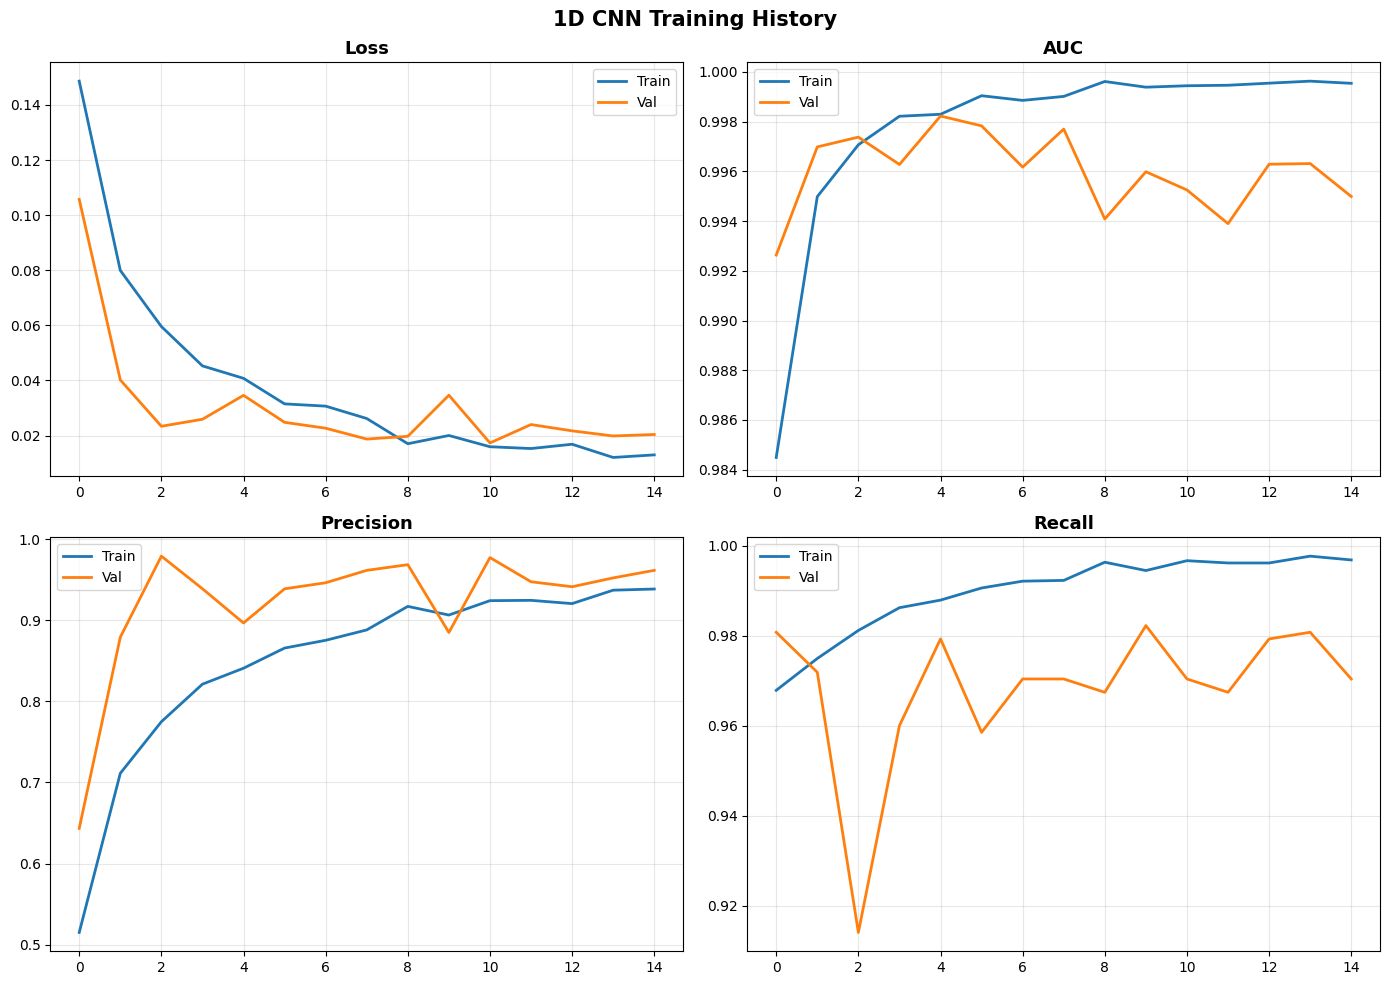


✅ Best model saved to: C:\order\Desktop\Gun\Shoot_Catcher\01_1D_CNN\output\1d_cnn_best.h5


In [8]:
# ============================================================
# CELL 8: Training
# ============================================================

# --- Callbacks ---
model_path = OUTPUT_DIR / '1d_cnn_best.h5'

training_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_auc',
        patience=10,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        str(model_path),
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
]

# --- Train ---
print(f'\n🚀 Training 1D CNN...\n')

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=training_callbacks,
    verbose=1
)

# --- Plot training history ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Train', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Val', linewidth=2)
axes[0, 0].set_title('Loss', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# AUC
axes[0, 1].plot(history.history['auc'], label='Train', linewidth=2)
axes[0, 1].plot(history.history['val_auc'], label='Val', linewidth=2)
axes[0, 1].set_title('AUC', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(history.history['precision'], label='Train', linewidth=2)
axes[1, 0].plot(history.history['val_precision'], label='Val', linewidth=2)
axes[1, 0].set_title('Precision', fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train', linewidth=2)
axes[1, 1].plot(history.history['val_recall'], label='Val', linewidth=2)
axes[1, 1].set_title('Recall', fontsize=13, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('1D CNN Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '1d_cnn_training_history.png', dpi=150)
plt.show()

print(f'\n✅ Best model saved to: {model_path}')

🔍 Evaluating on TEST set (entirely unseen source recordings)...

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Non-Gunshot     0.9989    0.9890    0.9939      8199
     Gunshot     0.8805    0.9866    0.9305       672

    accuracy                         0.9888      8871
   macro avg     0.9397    0.9878    0.9622      8871
weighted avg     0.9899    0.9888    0.9891      8871


KEY METRICS (What Actually Matters)
  ROC-AUC          : 0.9988
  PR-AUC           : 0.9847   ← Best for imbalanced data
  F2-Score         : 0.9634       ← Weights recall 2x over precision


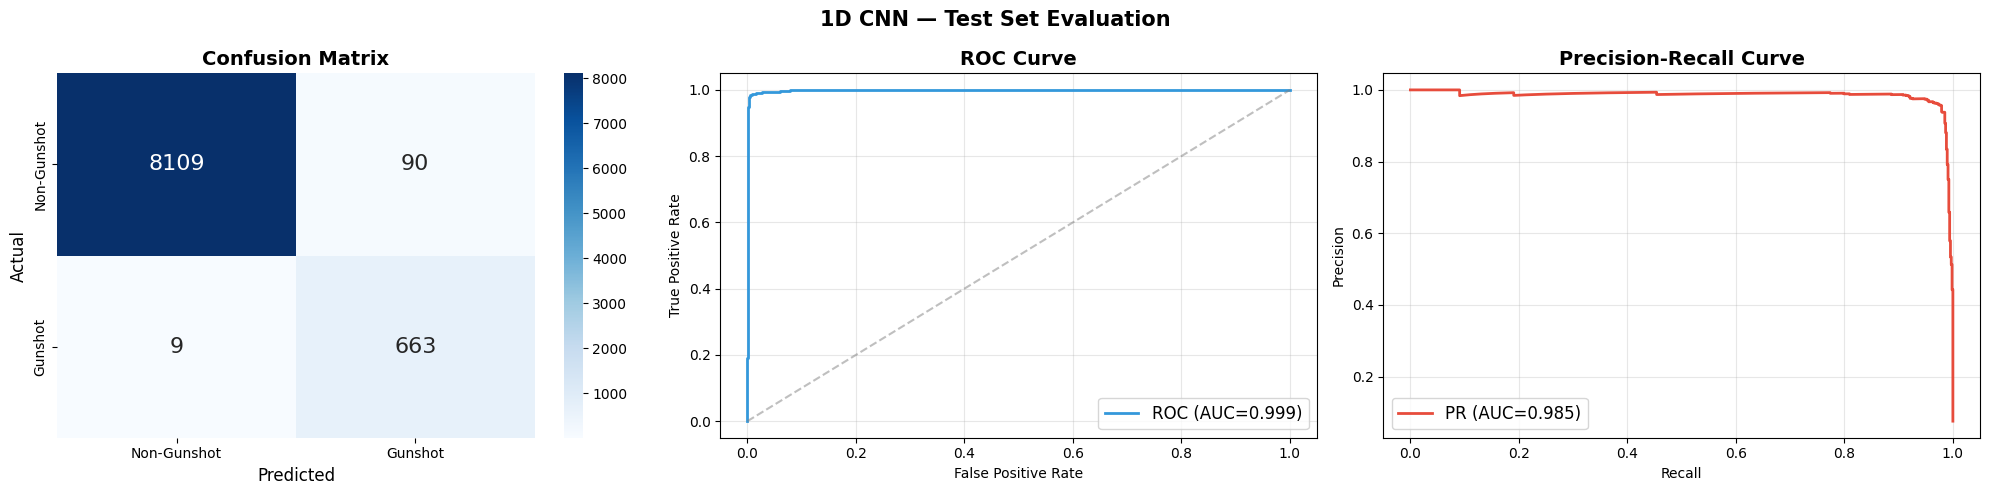


📊 Results saved to: C:\order\Desktop\Gun\Shoot_Catcher\01_1D_CNN\output\1d_cnn_results.json


In [9]:
# ============================================================
# CELL 9: Evaluation — Full Metrics Suite
# ============================================================

# --- Load best model ---
model = keras.models.load_model(str(model_path))

# --- Predict on test set ---
print('🔍 Evaluating on TEST set (entirely unseen source recordings)...\n')
y_pred_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

# --- Classification Report ---
print('=' * 60)
print('CLASSIFICATION REPORT')
print('=' * 60)
print(classification_report(y_test, y_pred,
                            target_names=['Non-Gunshot', 'Gunshot'],
                            digits=4))

# --- Key Metrics ---
roc_auc = roc_auc_score(y_test, y_pred_prob)
pr_auc = average_precision_score(y_test, y_pred_prob)
f2 = fbeta_score(y_test, y_pred, beta=2)

print(f'\n{"=" * 60}')
print(f'KEY METRICS (What Actually Matters)')
print(f'{"=" * 60}')
print(f'  ROC-AUC          : {roc_auc:.4f}')
print(f'  PR-AUC           : {pr_auc:.4f}   ← Best for imbalanced data')
print(f'  F2-Score         : {f2:.4f}       ← Weights recall 2x over precision')
print(f'{"=" * 60}')

# --- Confusion Matrix ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Gunshot', 'Gunshot'],
            yticklabels=['Non-Gunshot', 'Gunshot'],
            ax=axes[0], annot_kws={'size': 16})
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, linewidth=2, color='#3498db', label=f'ROC (AUC={roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

# Precision-Recall Curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_prob)
axes[2].plot(recall_curve, precision_curve, linewidth=2, color='#e74c3c',
             label=f'PR (AUC={pr_auc:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.suptitle('1D CNN — Test Set Evaluation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '1d_cnn_evaluation.png', dpi=150)
plt.show()

# --- Save results ---
results = {
    'model': '1D CNN',
    'sample_rate': SAMPLE_RATE,
    'clip_duration_ms': CLIP_DURATION_MS,
    'roc_auc': float(roc_auc),
    'pr_auc': float(pr_auc),
    'f2_score': float(f2),
    'train_size': len(y_train),
    'val_size': len(y_val),
    'test_size': len(y_test),
    'total_params': int(total_params),
    'timestamp': datetime.now().isoformat(),
}
(OUTPUT_DIR / '1d_cnn_results.json').write_text(json.dumps(results, indent=2))
print(f'\n📊 Results saved to: {OUTPUT_DIR / "1d_cnn_results.json"}')


ERROR ANALYSIS
False Positives (predicted GUNSHOT, actually NOISE): 90
False Negatives (predicted NOISE, actually GUNSHOT): 9


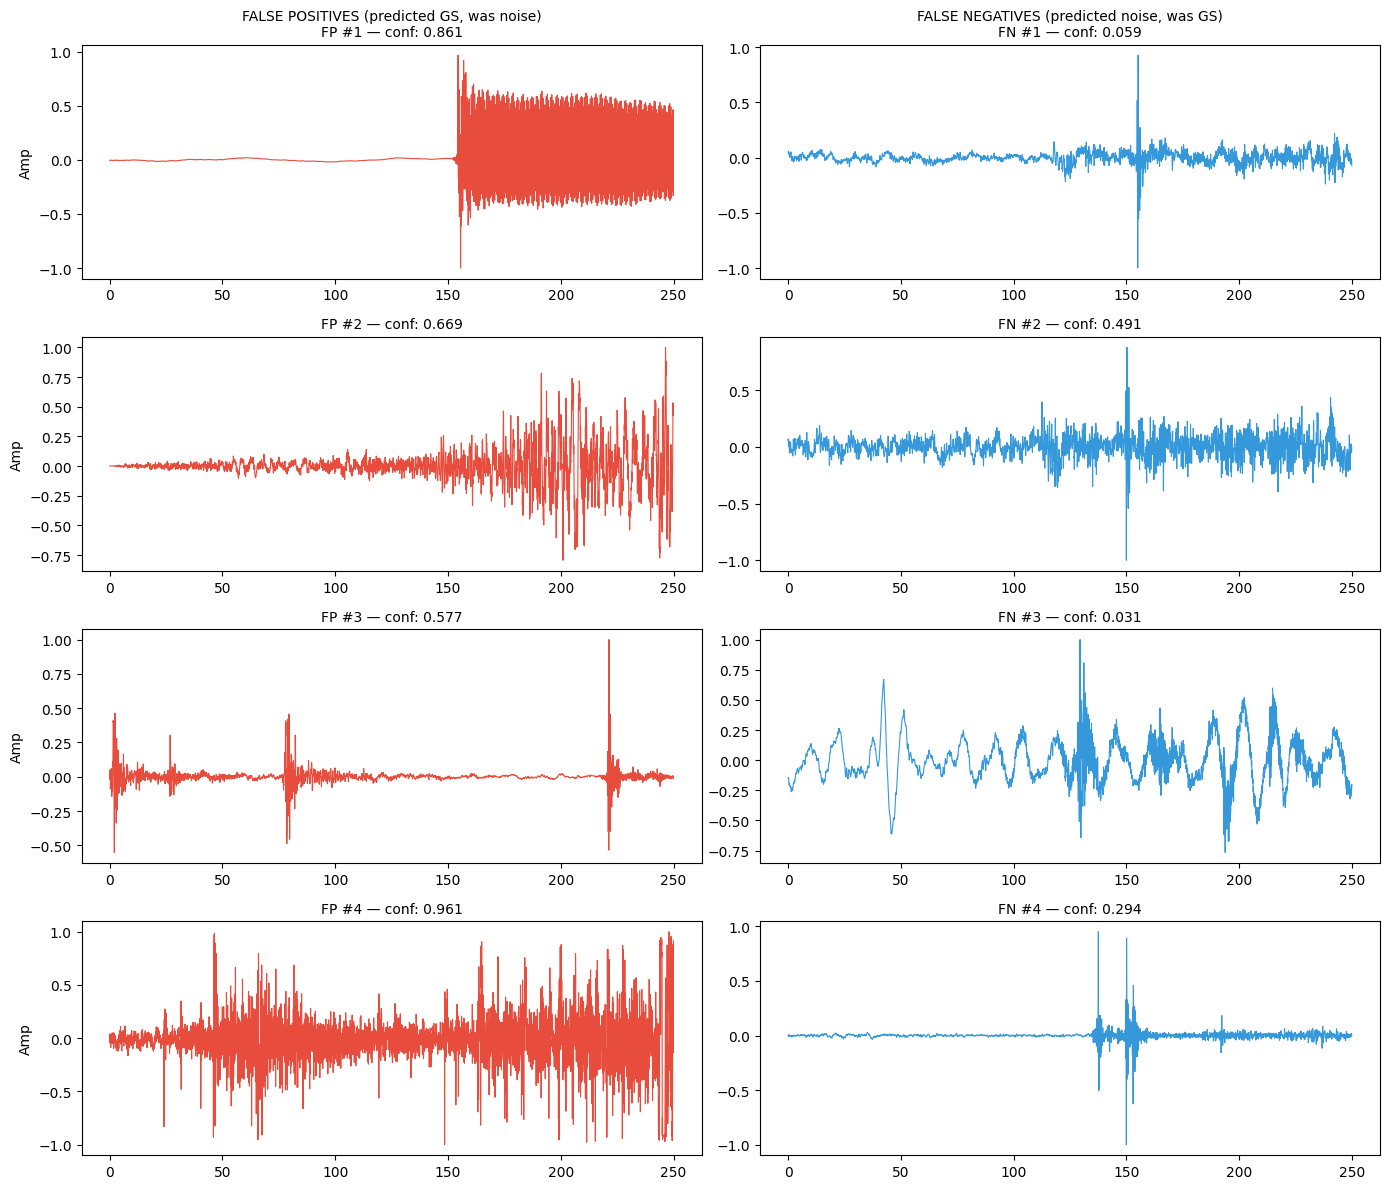


🔊 Missed gunshot (False Negative):



🔊 False alarm (False Positive):


In [10]:
# ============================================================
# CELL 10: Error Analysis — Listen to Mistakes
# ============================================================

# Find misclassified samples
false_positives = np.where((y_pred == 1) & (y_test == 0))[0]  # Predicted gunshot, was noise
false_negatives = np.where((y_pred == 0) & (y_test == 1))[0]  # Predicted noise, was gunshot

print(f'\n{"=" * 60}')
print(f'ERROR ANALYSIS')
print(f'{"=" * 60}')
print(f'False Positives (predicted GUNSHOT, actually NOISE): {len(false_positives)}')
print(f'False Negatives (predicted NOISE, actually GUNSHOT): {len(false_negatives)}')
print(f'{"=" * 60}')

# Plot and play misclassified samples
n_show = min(4, max(len(false_positives), len(false_negatives)))

if n_show > 0:
    fig, axes = plt.subplots(n_show, 2, figsize=(14, 3 * n_show))
    if n_show == 1:
        axes = axes.reshape(1, -1)
    
    for row in range(n_show):
        # False Positive
        if row < len(false_positives):
            idx = false_positives[row]
            waveform = X_test[idx].flatten()
            t = np.arange(len(waveform)) / SAMPLE_RATE * 1000
            axes[row, 0].plot(t, waveform, linewidth=0.8, color='#e74c3c')
            axes[row, 0].set_title(f'FP #{row+1} — conf: {y_pred_prob[idx]:.3f}', fontsize=10)
            axes[row, 0].set_ylabel('Amp')
        else:
            axes[row, 0].set_visible(False)
        
        # False Negative
        if row < len(false_negatives):
            idx = false_negatives[row]
            waveform = X_test[idx].flatten()
            t = np.arange(len(waveform)) / SAMPLE_RATE * 1000
            axes[row, 1].plot(t, waveform, linewidth=0.8, color='#3498db')
            axes[row, 1].set_title(f'FN #{row+1} — conf: {y_pred_prob[idx]:.3f}', fontsize=10)
        else:
            axes[row, 1].set_visible(False)
    
    axes[0, 0].set_title(f'FALSE POSITIVES (predicted GS, was noise)\nFP #1 — conf: {y_pred_prob[false_positives[0]]:.3f}' if len(false_positives) > 0 else '', fontsize=10)
    axes[0, 1].set_title(f'FALSE NEGATIVES (predicted noise, was GS)\nFN #1 — conf: {y_pred_prob[false_negatives[0]]:.3f}' if len(false_negatives) > 0 else '', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '1d_cnn_errors.png', dpi=150)
    plt.show()
    
    # Audio playback of mistakes
    if len(false_negatives) > 0:
        print('\n🔊 Missed gunshot (False Negative):')
        display(ipd.Audio(X_test[false_negatives[0]].flatten(), rate=SAMPLE_RATE))
    if len(false_positives) > 0:
        print('\n🔊 False alarm (False Positive):')
        display(ipd.Audio(X_test[false_positives[0]].flatten(), rate=SAMPLE_RATE))
else:
    print('\n🎉 Perfect classification! No errors to analyze.')

In [12]:
# ============================================================
# CELL 11: Model Export — H5 + TFLite (INT8 Quantized)
# ============================================================

# --- Save full Keras model ---
keras_path = OUTPUT_DIR / '1d_cnn_gunshot_detector.h5'
model.save(str(keras_path))
print(f'✅ Keras model saved: {keras_path}')
print(f'   Size: {os.path.getsize(keras_path) / 1024:.1f} KB')

# --- Convert to TFLite (float32) ---
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
tflite_path = OUTPUT_DIR / '1d_cnn_float32.tflite'
tflite_path.write_bytes(tflite_model)
print(f'\n✅ TFLite (float32) saved: {tflite_path}')
print(f'   Size: {len(tflite_model) / 1024:.1f} KB')

# --- Convert to TFLite (INT8 quantized) ---
def representative_dataset():
    """Provide sample data for INT8 calibration."""
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1]]

converter_q = tf.lite.TFLiteConverter.from_keras_model(model)
converter_q.optimizations = [tf.lite.Optimize.DEFAULT]
converter_q.representative_dataset = representative_dataset
converter_q.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_q.inference_input_type = tf.int8
converter_q.inference_output_type = tf.int8

try:
    tflite_quant = converter_q.convert()
    tflite_q_path = OUTPUT_DIR / '1d_cnn_int8.tflite'
    tflite_q_path.write_bytes(tflite_quant)
    print(f'\n✅ TFLite (INT8) saved: {tflite_q_path}')
    print(f'   Size: {len(tflite_quant) / 1024:.1f} KB')
    print(f'   Compression: {len(tflite_model)/len(tflite_quant):.1f}x smaller than float32')
except Exception as e:
    print(f'\n⚠️ INT8 quantization failed: {e}')
    print(f'   Float32 TFLite is still usable.')

# --- Also export at 16kHz if we trained at 22kHz ---
if SAMPLE_RATE == 22050:
    print(f'\n💡 To create a 16kHz version for Arduino, re-run with SAMPLE_RATE=16000')

print(f'\n{"=" * 50}')
print(f'EXPORT COMPLETE')
print(f'{"=" * 50}')
print(f'All outputs saved to: {OUTPUT_DIR}')
print(f'{"=" * 50}')

✅ Keras model saved: C:\order\Desktop\Gun\Shoot_Catcher\01_1D_CNN\output\1d_cnn_gunshot_detector.h5
   Size: 430.3 KB
INFO:tensorflow:Assets written to: C:\Users\jeeva\AppData\Local\Temp\tmptfj1trgb\assets


INFO:tensorflow:Assets written to: C:\Users\jeeva\AppData\Local\Temp\tmptfj1trgb\assets


Saved artifact at 'C:\Users\jeeva\AppData\Local\Temp\tmptfj1trgb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5512, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1472285052368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1472285051024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1472285164944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1472285164752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1472285166480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1472285166288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1472284789840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1472284790032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1472285177616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1472285176272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1472285166

INFO:tensorflow:Assets written to: C:\Users\jeeva\AppData\Local\Temp\tmpbg1dr3r8\assets


Saved artifact at 'C:\Users\jeeva\AppData\Local\Temp\tmpbg1dr3r8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5512, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1472285052368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1472285051024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1472285164944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1472285164752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1472285166480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1472285166288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1472284789840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1472284790032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1472285177616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1472285176272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1472285166